In [1]:
# =================== IMPORTS ===================
import os
import numpy as np
import random
import tensorflow as tf
import time
from tensorflow.keras import layers, models, callbacks, backend as K
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from keras.optimizers import AdamW
from tensorflow.keras.losses import CategoricalCrossentropy
from shutil import rmtree, copyfile
from tqdm import tqdm
from tensorflow.keras import mixed_precision

# =================== CUSTOM LAYERS ===================
@tf.keras.utils.register_keras_serializable()
class MeanChannel(layers.Layer):
    def call(self, inputs):
        return tf.reduce_mean(inputs, axis=-1, keepdims=True)

@tf.keras.utils.register_keras_serializable()
class MaxChannel(layers.Layer):
    def call(self, inputs):
        return tf.reduce_max(inputs, axis=-1, keepdims=True)

# =================== ENABLE MIXED PRECISION ===================
mixed_precision.set_global_policy('mixed_float16')

# =================== CONSTANTS ===================
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 4
EPOCHS = 60
train_ratio, val_ratio = 0.7, 0.15

# =================== DIRECTORIES ===================
dataset_dir = '/kaggle/input/colon-augmented-custom/colon_augmented_png_v9'
base_dir = '/kaggle/working/colon_split'

# =================== CLEAN EXISTING SPLITS ===================
if os.path.exists(base_dir):
    for folder in os.listdir(base_dir):
        rmtree(os.path.join(base_dir, folder))

# =================== DATA SPLIT ===================
splits = ['train', 'val', 'test']
class_names = os.listdir(dataset_dir)

for split in splits:
    for class_name in class_names:
        os.makedirs(os.path.join(base_dir, split, class_name), exist_ok=True)

for class_name in class_names:
    image_list = os.listdir(os.path.join(dataset_dir, class_name))
    random.shuffle(image_list)

    n_total = len(image_list)
    n_train = int(train_ratio * n_total)
    n_val = int(val_ratio * n_total)

    train_files = image_list[:n_train]
    val_files = image_list[n_train:n_train + n_val]
    test_files = image_list[n_train + n_val:]

    for split, split_files in zip(['train', 'val', 'test'], [train_files, val_files, test_files]):
        for img in tqdm(split_files, desc=f'{class_name} - {split}'):
            src = os.path.join(dataset_dir, class_name, img)
            dst = os.path.join(base_dir, split, class_name, img)
            copyfile(src, dst)

# =================== DATA GENERATORS ===================
train_datagen = ImageDataGenerator(
    rescale=1./255,
    preprocessing_function=tf.keras.applications.efficientnet.preprocess_input
)
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    os.path.join(base_dir, 'train'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_test_datagen.flow_from_directory(
    os.path.join(base_dir, 'val'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = val_test_datagen.flow_from_directory(
    os.path.join(base_dir, 'test'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# =================== MODEL BUILDING ===================
def cbam_block(input_feature, ratio=8):
    channel = input_feature.shape[-1]

    avg_pool = layers.GlobalAveragePooling2D()(input_feature)
    max_pool = layers.GlobalMaxPooling2D()(input_feature)

    shared_dense_one = layers.Dense(channel // ratio, activation='relu')
    shared_dense_two = layers.Dense(channel)

    mlp_avg = shared_dense_two(shared_dense_one(avg_pool))
    mlp_max = shared_dense_two(shared_dense_one(max_pool))

    channel_attention = layers.Add()([mlp_avg, mlp_max])
    channel_attention = layers.Activation('sigmoid')(channel_attention)
    channel_attention = layers.Reshape((1, 1, channel))(channel_attention)

    x = layers.Multiply()([input_feature, channel_attention])

    avg_pool_spatial = MeanChannel()(x)
    max_pool_spatial = MaxChannel()(x)
    concat = layers.Concatenate(axis=-1)([avg_pool_spatial, max_pool_spatial])
    spatial_attention = layers.Conv2D(1, kernel_size=7, padding='same', activation='sigmoid')(concat)

    refined_feature = layers.Multiply()([x, spatial_attention])
    return refined_feature

def build_model():
    base_model = tf.keras.applications.EfficientNetB0(
        include_top=False, input_shape=(224, 224, 3), weights='imagenet'
    )
    base_model.trainable = True

    inputs = layers.Input(shape=(224, 224, 3))
    x = base_model(inputs, training=True)
    x = cbam_block(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax', dtype='float32')(x)

    model = tf.keras.Model(inputs, outputs)
    return model

model = build_model()

# =================== OPTIMIZER & LOSS ===================
lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1.5e-3,
    decay_steps=1000,
    alpha=1e-6
)
optimizer = AdamW(learning_rate=lr_schedule, weight_decay=1e-5)
loss_fn = CategoricalCrossentropy(label_smoothing=0.1)

model.compile(optimizer=optimizer, loss=loss_fn, metrics=['accuracy'])

# =================== PARAMETER COUNT ===================
trainable_params = np.sum([K.count_params(w) for w in model.trainable_weights])
non_trainable_params = np.sum([K.count_params(w) for w in model.non_trainable_weights])
total_params = trainable_params + non_trainable_params

print(f"\n📊 Model Parameter Counts:")
print(f"  Total: {total_params:,}")
print(f"  Trainable: {trainable_params:,}")
print(f"  Non-trainable: {non_trainable_params:,}\n")

# =================== CALLBACKS ===================
checkpoint_cb = callbacks.ModelCheckpoint(
    'carenet.keras', monitor='val_accuracy', save_best_only=True, verbose=1
)
earlystop_cb = callbacks.EarlyStopping(
    monitor='val_accuracy', patience=7, restore_best_weights=True
)

# =================== TRAINING WITH TIMING ===================
start_time = time.time()

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=[checkpoint_cb, earlystop_cb],
    verbose=1
)

end_time = time.time()
total_training_time = end_time - start_time
avg_epoch_time = total_training_time / len(history.epoch)

print(f"\n⏱️ Total Training Time: {total_training_time:.2f} seconds")
print(f"⏱️ Average Time per Epoch: {avg_epoch_time:.2f} seconds")

# =================== EVALUATION ===================
model.load_weights("carenet.keras")
test_loss, test_acc = model.evaluate(test_generator)
print(f"\n✅ Test Accuracy: {test_acc:.4f}")


2025-09-07 05:23:29.621876: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1757222609.943562      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1757222610.031973      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
1_ulcerative_colitis - test: 100%|██████████| 225/225 [00:02<00:00, 96.58it/s] 


Found 4200 images belonging to 4 classes.
Found 900 images belonging to 4 classes.
Found 900 images belonging to 4 classes.


I0000 00:00:1757222690.629999      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1757222690.630769      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

📊 Model Parameter Counts:
  Total: 5,118,634.0
  Trainable: 5,076,611
  Non-trainable: 42,023.0



/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/60


I0000 00:00:1757222757.769990     119 service.cc:148] XLA service 0x7ecb14001f40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1757222757.771705     119 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1757222757.771730     119 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1757222765.773120     119 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1757222815.738508     119 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 485ms/step - accuracy: 0.7799 - loss: 0.7572
Epoch 1: val_accuracy improved from -inf to 0.25778, saving model to carenet.keras
132/132 ━━━━━━━━━━━━━━━━━━━━ 205s 631ms/step - accuracy: 0.7807 - loss: 0.7559 - val_accuracy: 0.2578 - val_loss: 1.3923
Epoch 2/60
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.9620 - loss: 0.4434
Epoch 2: val_accuracy did not improve from 0.25778
132/132 ━━━━━━━━━━━━━━━━━━━━ 13s 97ms/step - accuracy: 0.9620 - loss: 0.4433 - val_accuracy: 0.2500 - val_loss: 1.7296
Epoch 3/60
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.9783 - loss: 0.4123
Epoch 3: val_accuracy improved from 0.25778 to 0.30778, saving model to carenet.keras
132/132 ━━━━━━━━━━━━━━━━━━━━ 14s 106ms/step - accuracy: 0.9783 - loss: 0.4122 - val_accuracy: 0.3078 - val_loss: 1.4907
Epoch 4/60
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.9906 - loss: 0.3803
Epoch 4: val_accuracy did not improve from 0.30778
132/132 ━━━━━━━━━━━━━━━━━━━━ 13

In [1]:
# =================== IMPORTS ===================
import os
import numpy as np
import random
import tensorflow as tf
import time
from tensorflow.keras import layers, models, callbacks, backend as K
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from keras.optimizers import AdamW
from tensorflow.keras.losses import CategoricalCrossentropy
from shutil import rmtree, copyfile
from tqdm import tqdm
from tensorflow.keras import mixed_precision

# =================== CUSTOM LAYERS ===================
@tf.keras.utils.register_keras_serializable()
class MeanChannel(layers.Layer):
    def call(self, inputs):
        return tf.reduce_mean(inputs, axis=-1, keepdims=True)

@tf.keras.utils.register_keras_serializable()
class MaxChannel(layers.Layer):
    def call(self, inputs):
        return tf.reduce_max(inputs, axis=-1, keepdims=True)

# =================== ENABLE MIXED PRECISION ===================
mixed_precision.set_global_policy('mixed_float16')

# =================== CONSTANTS ===================
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 4
EPOCHS = 60
train_ratio, val_ratio = 0.7, 0.15

# =================== DIRECTORIES ===================
dataset_dir = '/kaggle/input/colon-augmented-custom/colon_augmented_png_v9'
base_dir = '/kaggle/working/colon_split'

# =================== CLEAN EXISTING SPLITS ===================
if os.path.exists(base_dir):
    for folder in os.listdir(base_dir):
        rmtree(os.path.join(base_dir, folder))

# =================== DATA SPLIT ===================
splits = ['train', 'val', 'test']
class_names = os.listdir(dataset_dir)

for split in splits:
    for class_name in class_names:
        os.makedirs(os.path.join(base_dir, split, class_name), exist_ok=True)

for class_name in class_names:
    image_list = os.listdir(os.path.join(dataset_dir, class_name))
    random.shuffle(image_list)

    n_total = len(image_list)
    n_train = int(train_ratio * n_total)
    n_val = int(val_ratio * n_total)

    train_files = image_list[:n_train]
    val_files = image_list[n_train:n_train + n_val]
    test_files = image_list[n_train + n_val:]

    for split, split_files in zip(['train', 'val', 'test'], [train_files, val_files, test_files]):
        for img in tqdm(split_files, desc=f'{class_name} - {split}'):
            src = os.path.join(dataset_dir, class_name, img)
            dst = os.path.join(base_dir, split, class_name, img)
            copyfile(src, dst)

# =================== DATA GENERATORS ===================
train_datagen = ImageDataGenerator(
    rescale=1./255,
    preprocessing_function=tf.keras.applications.efficientnet.preprocess_input
)
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    os.path.join(base_dir, 'train'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_test_datagen.flow_from_directory(
    os.path.join(base_dir, 'val'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = val_test_datagen.flow_from_directory(
    os.path.join(base_dir, 'test'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# =================== MODEL BUILDING ===================
def cbam_block(input_feature, ratio=8):
    channel = input_feature.shape[-1]

    avg_pool = layers.GlobalAveragePooling2D()(input_feature)
    max_pool = layers.GlobalMaxPooling2D()(input_feature)

    shared_dense_one = layers.Dense(channel // ratio, activation='relu')
    shared_dense_two = layers.Dense(channel)

    mlp_avg = shared_dense_two(shared_dense_one(avg_pool))
    mlp_max = shared_dense_two(shared_dense_one(max_pool))

    channel_attention = layers.Add()([mlp_avg, mlp_max])
    channel_attention = layers.Activation('sigmoid')(channel_attention)
    channel_attention = layers.Reshape((1, 1, channel))(channel_attention)

    x = layers.Multiply()([input_feature, channel_attention])

    avg_pool_spatial = MeanChannel()(x)
    max_pool_spatial = MaxChannel()(x)
    concat = layers.Concatenate(axis=-1)([avg_pool_spatial, max_pool_spatial])
    spatial_attention = layers.Conv2D(1, kernel_size=7, padding='same', activation='sigmoid')(concat)

    refined_feature = layers.Multiply()([x, spatial_attention])
    return refined_feature

def build_model():
    base_model = tf.keras.applications.EfficientNetB0(
        include_top=False, input_shape=(224, 224, 3), weights='imagenet'
    )
    base_model.trainable = True

    inputs = layers.Input(shape=(224, 224, 3))
    x = base_model(inputs, training=True)
    x = cbam_block(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax', dtype='float32')(x)

    model = tf.keras.Model(inputs, outputs)
    return model

model = build_model()

# =================== OPTIMIZER & LOSS ===================
lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1.5e-3,
    decay_steps=1000,
    alpha=1e-6
)
optimizer = AdamW(learning_rate=lr_schedule, weight_decay=1e-5)
loss_fn = CategoricalCrossentropy(label_smoothing=0.1)

model.compile(optimizer=optimizer, loss=loss_fn, metrics=['accuracy'])

# =================== PARAMETER COUNT ===================
trainable_params = np.sum([K.count_params(w) for w in model.trainable_weights])
non_trainable_params = np.sum([K.count_params(w) for w in model.non_trainable_weights])
total_params = trainable_params + non_trainable_params

print(f"\n📊 Model Parameter Counts:")
print(f"  Total: {total_params:,}")
print(f"  Trainable: {trainable_params:,}")
print(f"  Non-trainable: {non_trainable_params:,}\n")

# =================== CALLBACKS ===================
checkpoint_cb = callbacks.ModelCheckpoint(
    'carenet.keras', monitor='val_accuracy', save_best_only=True, verbose=1
)
earlystop_cb = callbacks.EarlyStopping(
    monitor='val_accuracy', patience=7, restore_best_weights=True
)

# =================== TRAINING WITH TIMING ===================
start_time = time.time()

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=[checkpoint_cb, earlystop_cb],
    verbose=1
)

end_time = time.time()
total_training_time = end_time - start_time
avg_epoch_time = total_training_time / len(history.epoch)

print(f"\n⏱️ Total Training Time: {total_training_time:.2f} seconds")
print(f"⏱️ Average Time per Epoch: {avg_epoch_time:.2f} seconds")

# =================== EVALUATION ===================
model.load_weights("carenet.keras")
test_loss, test_acc = model.evaluate(test_generator)
print(f"\n✅ Test Accuracy: {test_acc:.4f}")

2025-09-17 15:38:24.598539: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1758123504.926120      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1758123505.017867      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
1_ulcerative_colitis - test: 100%|██████████| 225/225 [00:01<00:00, 184.61it/s]


Found 4200 images belonging to 4 classes.
Found 900 images belonging to 4 classes.
Found 900 images belonging to 4 classes.


I0000 00:00:1758123558.969586      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1758123558.970277      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

📊 Model Parameter Counts:
  Total: 5,118,634.0
  Trainable: 5,076,611
  Non-trainable: 42,023.0



/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/60


I0000 00:00:1758123631.668050     120 service.cc:148] XLA service 0x7d9e800411a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1758123631.669173     120 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1758123631.669197     120 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1758123640.058019     120 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1758123693.242243     120 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 525ms/step - accuracy: 0.7793 - loss: 0.7384
Epoch 1: val_accuracy improved from -inf to 0.25000, saving model to carenet.keras
132/132 ━━━━━━━━━━━━━━━━━━━━ 220s 676ms/step - accuracy: 0.7801 - loss: 0.7372 - val_accuracy: 0.2500 - val_loss: 1.6320
Epoch 2/60
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.9640 - loss: 0.4329
Epoch 2: val_accuracy did not improve from 0.25000
132/132 ━━━━━━━━━━━━━━━━━━━━ 15s 109ms/step - accuracy: 0.9640 - loss: 0.4329 - val_accuracy: 0.2500 - val_loss: 1.8576
Epoch 3/60
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.9797 - loss: 0.4022
Epoch 3: val_accuracy improved from 0.25000 to 0.47000, saving model to carenet.keras
132/132 ━━━━━━━━━━━━━━━━━━━━ 16s 120ms/step - accuracy: 0.9797 - loss: 0.4021 - val_accuracy: 0.4700 - val_loss: 1.5007
Epoch 4/60
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.9869 - loss: 0.3859
Epoch 4: val_accuracy did not improve from 0.47000
132/132 ━━━━━━━━━━━━━━━━━━━━ 1

In [3]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetb0      │ (None, 7, 7,      │  4,049,571 │ input_layer_1[0]… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ efficientnetb0[0… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 1280)      │          0 │ efficientnetb0[0… │
│ (GlobalMaxPooling2… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 160)       │    204,960 │ global_average_p… │
│                     │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1280)      │    206,080 │ dense[0][0],      │
│                     │                   │            │ dense[1][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 1280)      │          0 │ dense_1[0][0],    │
│                     │                   │            │ dense_1[1][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 1280)      │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 1,      │          0 │ activation[0][0]  │
│                     │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 7, 7,      │          0 │ efficientnetb0[0… │
│                     │ 1280)             │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mean_channel        │ (None, 7, 7, 1)   │          0 │ multiply[0][0]    │
│ (MeanChannel)       │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_channel         │ (None, 7, 7, 1)   │          0 │ multiply[0][0]    │
│ (MaxChannel)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 7, 7, 2)   │          0 │ mean_channel[0][… │
│ (Concatenate)       │                   │            │ max_channel[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 7, 7, 1)   │         99 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_1          │ (None, 7, 7,      │          0 │ multiply[0][0],   │
│ (Multiply)          │ 1280)             │            │ conv2d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ multiply_1[0][0]  │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 1280)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 5,118,634 (19.53 MB)

 Trainable params: 5,076,611 (19.37 MB)

 Non-trainable params: 42,023 (164.16 KB)

# CAM

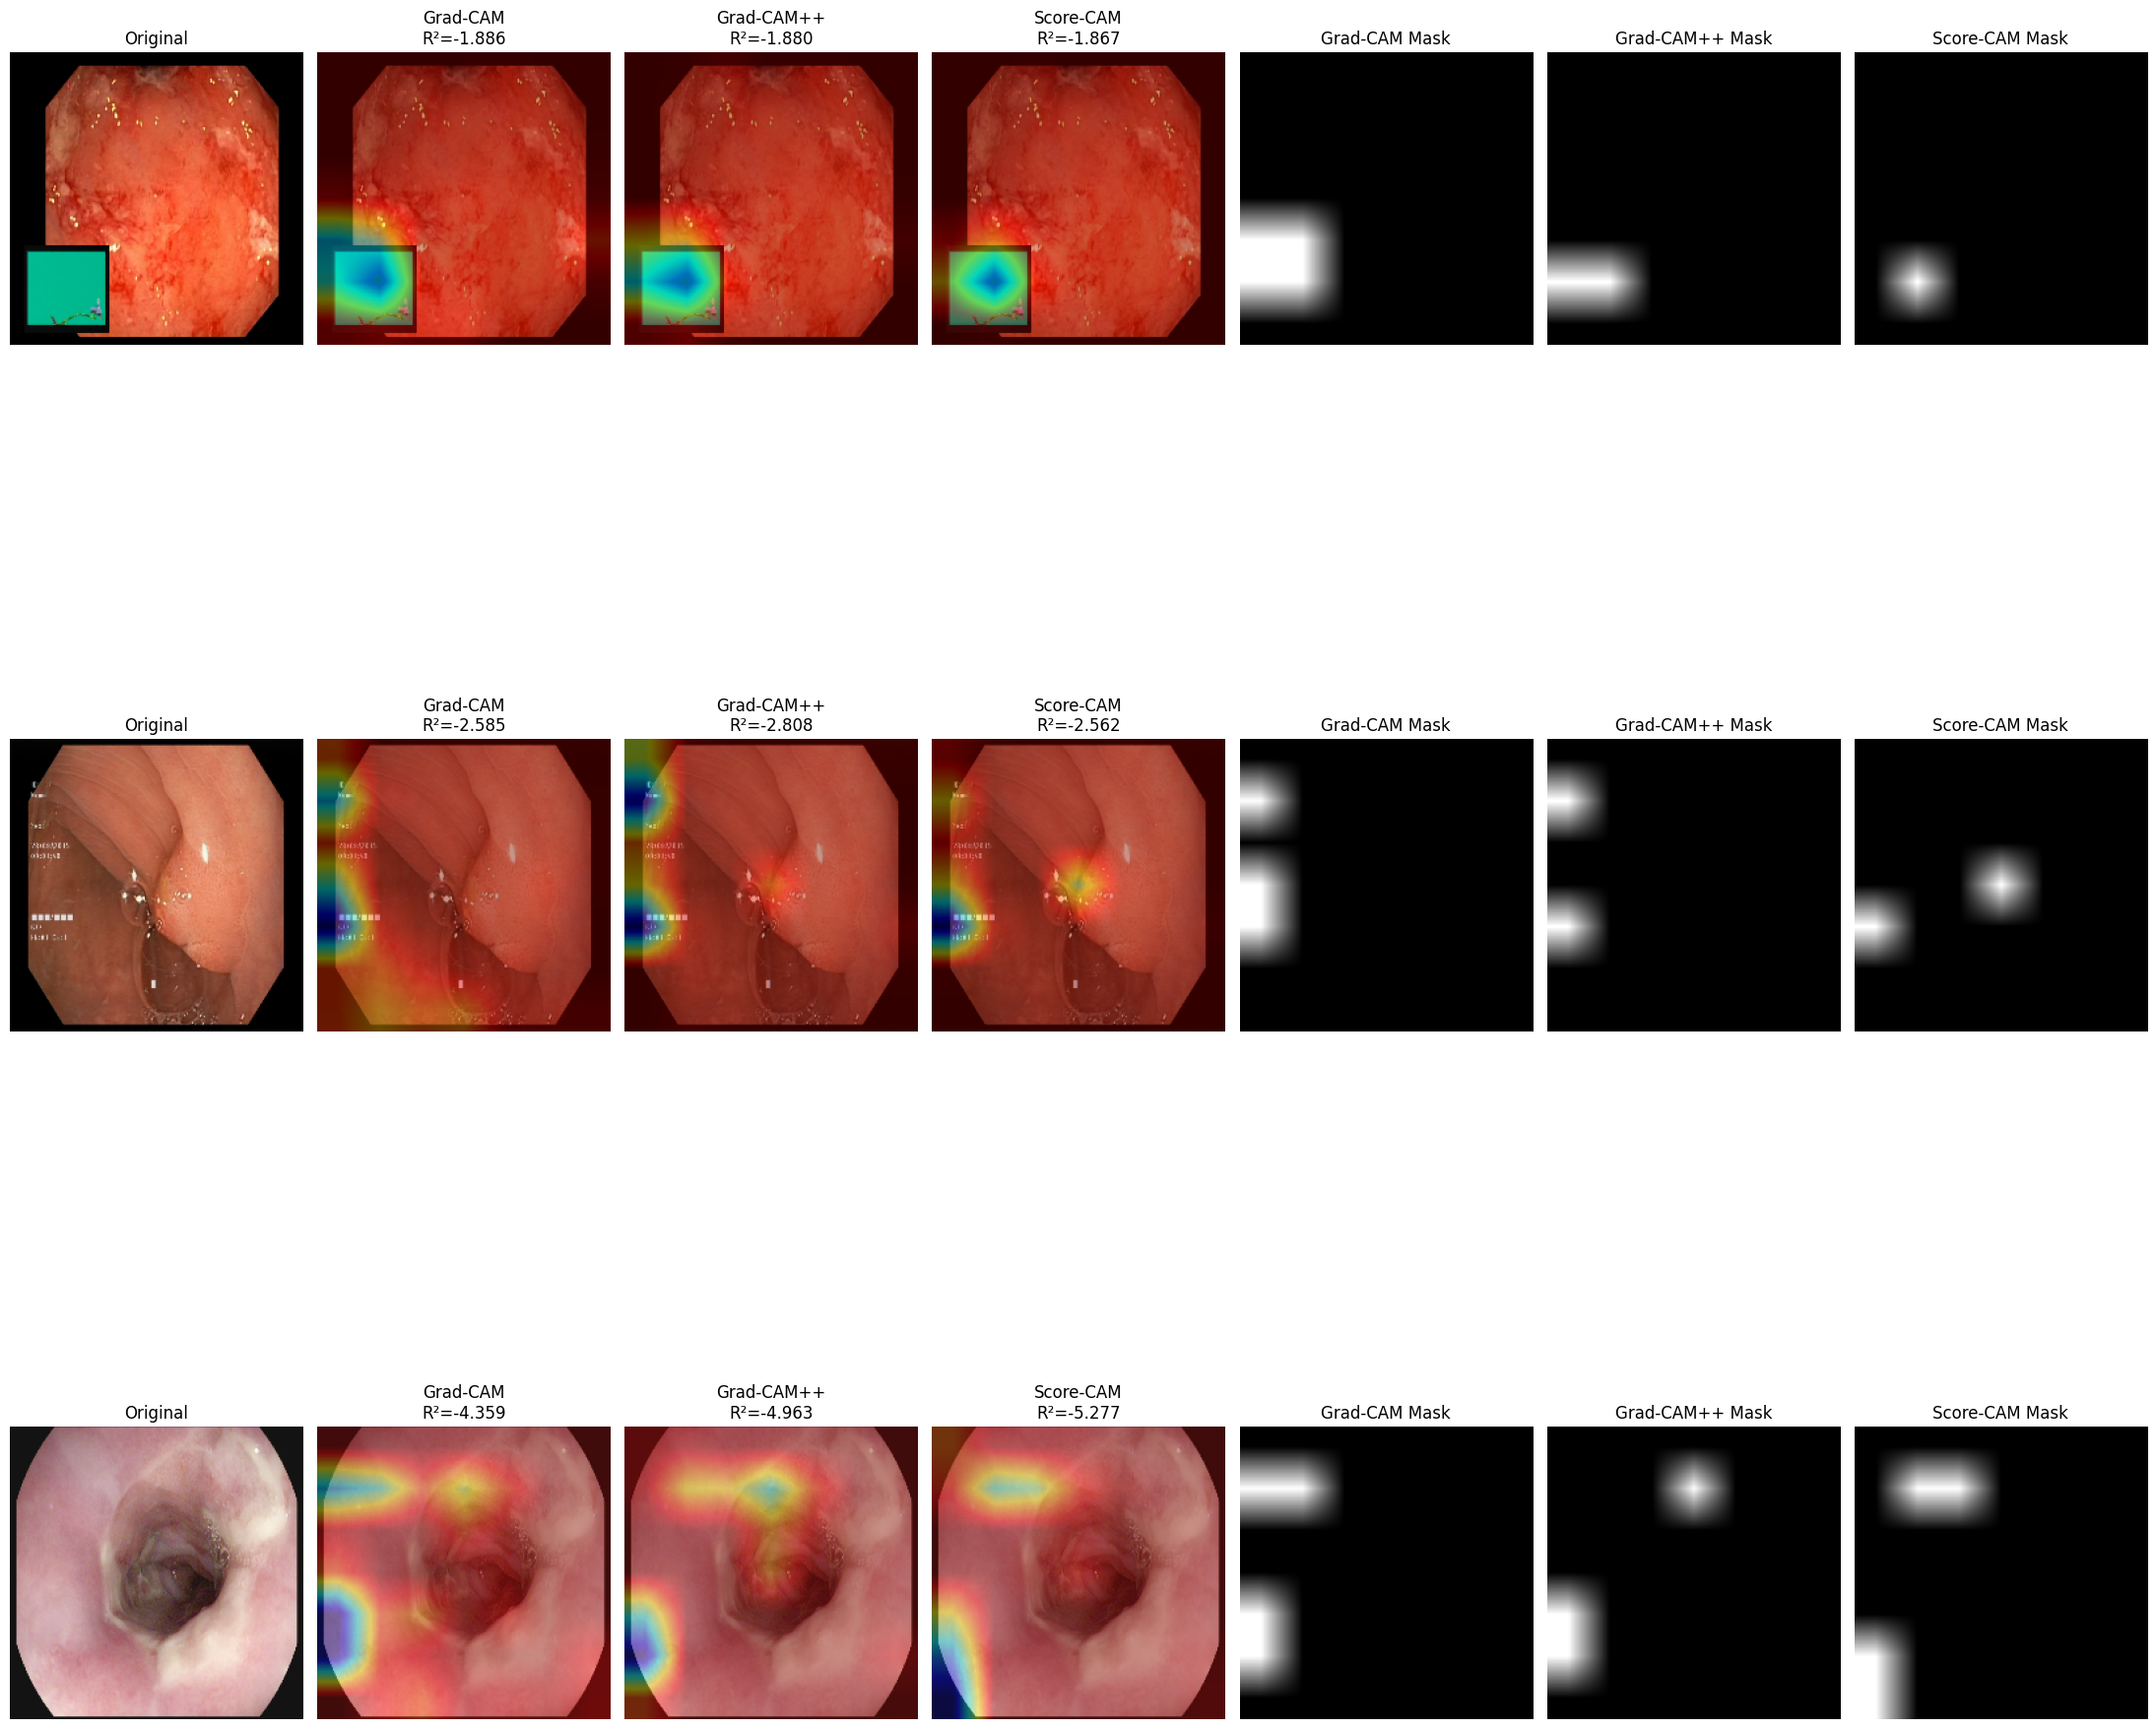

### 🔎 R² Scores for CAM Methods

| Class                |   Grad-CAM R² |   Grad-CAM++ R² |   Score-CAM R² |
|:---------------------|--------------:|----------------:|---------------:|
| 1_ulcerative_colitis |        -1.886 |          -1.88  |         -1.867 |
| 2_polyps             |        -2.585 |          -2.808 |         -2.562 |
| 3_esophagitis        |        -4.359 |          -4.963 |         -5.277 |


In [20]:
# =================== IMPORTS ===================
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2
from tensorflow.keras.layers import Layer
from sklearn.metrics import r2_score
import pandas as pd

# =================== CUSTOM LAYERS ===================
@tf.keras.utils.register_keras_serializable()
class MeanChannel(Layer):
    def call(self, inputs):
        return tf.reduce_mean(inputs, axis=-1, keepdims=True)

@tf.keras.utils.register_keras_serializable()
class MaxChannel(Layer):
    def call(self, inputs):
        return tf.reduce_max(inputs, axis=-1, keepdims=True)

# =================== CONFIG ===================
IMAGE_SIZE = (224, 224)
MODEL_PATH = '/kaggle/working/carenet.keras'
LAST_CONV_LAYER_NAME = 'multiply_1'
TOP_K_CHANNELS = 100

# Fixed image paths for each class
FIXED_IMAGES = {
    '1_ulcerative_colitis': '/kaggle/input/colon-augmented-custom/colon_augmented_png_v9/1_ulcerative_colitis/test_ulcer_ (12)_aug.png',
    '2_polyps': '/kaggle/input/colon-augmented-custom/colon_augmented_png_v9/2_polyps/test_polyps_ (10)_aug.png',
    '3_esophagitis': '/kaggle/input/colon-augmented-custom/colon_augmented_png_v9/3_esophagitis/test_esophagitis_ (39)_aug.png'
}

# =================== LOAD MODEL ===================
model = tf.keras.models.load_model(MODEL_PATH, compile=False, custom_objects={
    'MeanChannel': MeanChannel,
    'MaxChannel': MaxChannel
})

# =================== GRAD-CAM MODEL SETUP ===================
grad_model = tf.keras.models.Model(
    inputs=model.input,
    outputs=[model.get_layer(LAST_CONV_LAYER_NAME).output, model.output]
)

# =================== CAM FUNCTIONS ===================
def get_gradcam(img_array):
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        pred_index = tf.argmax(predictions[0])
        loss = predictions[:, pred_index]
    grads = tape.gradient(loss, conv_outputs)[0]
    if grads is None:
        return np.zeros(conv_outputs.shape[1:3])
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1))
    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)
    heatmap = tf.maximum(heatmap, 0)
    heatmap /= (tf.reduce_max(heatmap) + tf.keras.backend.epsilon())
    return heatmap.numpy()

def get_gradcam_plusplus(img_array):
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        pred_index = tf.argmax(predictions[0])
        loss = predictions[:, pred_index]
    grads = tape.gradient(loss, conv_outputs)[0]
    if grads is None:
        return np.zeros(conv_outputs.shape[1:3])
    conv_outputs = conv_outputs[0].numpy()
    grads = grads.numpy()
    alpha_num = grads**2
    alpha_denom = grads**2 * 2.0 + np.sum(conv_outputs * (grads**3)[:, :, np.newaxis], axis=-1, keepdims=True)
    alphas = alpha_num / (alpha_denom + 1e-7)
    weights = np.maximum(grads, 0.0)
    weights = np.sum(alphas * weights, axis=(0, 1))
    heatmap = np.sum(conv_outputs * weights, axis=-1)
    heatmap = np.maximum(heatmap, 0)
    heatmap /= (np.max(heatmap) + 1e-7)
    return heatmap

def get_scorecam(img_array, target_class_idx):
    conv_layer_model = tf.keras.models.Model(
        inputs=model.input,
        outputs=model.get_layer(LAST_CONV_LAYER_NAME).output
    )
    conv_outputs = conv_layer_model(img_array)[0].numpy()
    channel_weights = np.max(conv_outputs, axis=(0, 1))
    top_k_indices = np.argsort(channel_weights)[-TOP_K_CHANNELS:]
    heatmap = np.zeros(conv_outputs.shape[0:2])
    for i in top_k_indices:
        activation_map = conv_outputs[:, :, i]
        if np.max(activation_map) - np.min(activation_map) < 1e-8:
            continue
        norm_activation = (activation_map - np.min(activation_map)) / (np.max(activation_map) - np.min(activation_map) + 1e-8)
        resized_activation = cv2.resize(norm_activation.astype(np.float32), (IMAGE_SIZE[1], IMAGE_SIZE[0]))
        masked_input = img_array.copy() * resized_activation[np.newaxis, ..., np.newaxis]
        pred = model.predict(masked_input, verbose=0)[0]
        score = pred[target_class_idx]
        heatmap += score * activation_map
    if np.max(heatmap) - np.min(heatmap) < 1e-8:
        heatmap = np.zeros_like(heatmap)
    else:
        heatmap = np.maximum(heatmap, 0)
        heatmap = (heatmap - np.min(heatmap)) / (np.max(heatmap) + 1e-8)
    return heatmap

# =================== VISUAL HELPERS ===================
def overlay_on_image(original, heatmap, alpha=0.4):
    heatmap = np.array(heatmap, dtype=np.float32)
    if heatmap.ndim == 3:
        heatmap = np.mean(heatmap, axis=-1)
    heatmap = (heatmap - np.min(heatmap)) / (np.max(heatmap) + 1e-8)
    heatmap_resized = cv2.resize(heatmap, (original.shape[1], original.shape[0]))
    heatmap_uint8 = np.uint8(255 * heatmap_resized)
    heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    return cv2.addWeighted(original, 1-alpha, heatmap_color, alpha, 0)

def overlay_with_mask(original, heatmap, threshold=0.5):
    if heatmap.ndim > 2:
        heatmap = np.mean(heatmap, axis=-1)
    heatmap = (heatmap - np.min(heatmap)) / (np.max(heatmap) + 1e-8)
    mask = np.where(heatmap >= threshold, 1.0, 0.0)
    mask_resized = cv2.resize(mask, (original.shape[1], original.shape[0]))
    return (mask_resized * 255).astype(np.uint8)

def calculate_r2(original, heatmap):
    if heatmap is None or heatmap.size == 0:
        return np.nan
    heatmap = np.array(heatmap, dtype=np.float32)
    if heatmap.ndim == 3:
        heatmap = np.mean(heatmap, axis=-1)
    resized_map = cv2.resize(heatmap, (original.shape[1], original.shape[0]))
    gray_true = cv2.cvtColor(original, cv2.COLOR_RGB2GRAY).astype(np.float32)
    gray_true = (gray_true / 255.0).flatten()
    resized_map = (resized_map - np.min(resized_map)) / (np.max(resized_map) + 1e-8)
    return r2_score(gray_true, resized_map.flatten())

# =================== VISUALIZATION + R² ===================
results = []
plt.figure(figsize=(22, 8 * len(FIXED_IMAGES)))
plot_idx = 1

for class_name, image_path in FIXED_IMAGES.items():
    original = cv2.imread(image_path)
    if original is None:
        print(f"⚠️ Could not read image: {image_path}")
        continue
    original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
    resized = cv2.resize(original, IMAGE_SIZE)
    img_array = tf.keras.applications.efficientnet.preprocess_input(resized.astype('float32'))
    input_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(input_array, verbose=0)[0]
    pred_class = np.argmax(pred)

    # Grad-CAM
    gradcam = get_gradcam(input_array)
    grad_overlay = overlay_on_image(original, gradcam)
    grad_mask = overlay_with_mask(original, gradcam)
    r2_grad = calculate_r2(original, gradcam)

    # Grad-CAM++
    gradpp = get_gradcam_plusplus(input_array)
    gradpp_overlay = overlay_on_image(original, gradpp)
    gradpp_mask = overlay_with_mask(original, gradpp)
    r2_gradpp = calculate_r2(original, gradpp)

    # Score-CAM
    scorecam = get_scorecam(input_array, pred_class)
    score_overlay = overlay_on_image(original, scorecam)
    score_mask = overlay_with_mask(original, scorecam)
    r2_scorec = calculate_r2(original, scorecam)

    results.append({
        "Class": class_name,
        "Grad-CAM R²": round(r2_grad, 3),
        "Grad-CAM++ R²": round(r2_gradpp, 3),
        "Score-CAM R²": round(r2_scorec, 3)
    })

    # Plots: Original, overlays, masks
    plt.subplot(len(FIXED_IMAGES), 7, plot_idx); plt.imshow(original); plt.title("Original"); plt.axis("off"); plot_idx+=1
    plt.subplot(len(FIXED_IMAGES), 7, plot_idx); plt.imshow(grad_overlay); plt.title(f"Grad-CAM\nR²={r2_grad:.3f}"); plt.axis("off"); plot_idx+=1
    plt.subplot(len(FIXED_IMAGES), 7, plot_idx); plt.imshow(gradpp_overlay); plt.title(f"Grad-CAM++\nR²={r2_gradpp:.3f}"); plt.axis("off"); plot_idx+=1
    plt.subplot(len(FIXED_IMAGES), 7, plot_idx); plt.imshow(score_overlay); plt.title(f"Score-CAM\nR²={r2_scorec:.3f}"); plt.axis("off"); plot_idx+=1
    plt.subplot(len(FIXED_IMAGES), 7, plot_idx); plt.imshow(grad_mask, cmap="gray"); plt.title("Grad-CAM Mask"); plt.axis("off"); plot_idx+=1
    plt.subplot(len(FIXED_IMAGES), 7, plot_idx); plt.imshow(gradpp_mask, cmap="gray"); plt.title("Grad-CAM++ Mask"); plt.axis("off"); plot_idx+=1
    plt.subplot(len(FIXED_IMAGES), 7, plot_idx); plt.imshow(score_mask, cmap="gray"); plt.title("Score-CAM Mask"); plt.axis("off"); plot_idx+=1

plt.tight_layout()
plt.savefig("cam_overlay_mask_with_r2.png", dpi=200, bbox_inches="tight")
plt.show()

# =================== SUMMARY TABLE ===================
df_results = pd.DataFrame(results)
print("### 🔎 R² Scores for CAM Methods\n")
print(df_results.to_markdown(index=False))


# **Lime**

  0%|          | 0/1000 [00:00<?, ?it/s]

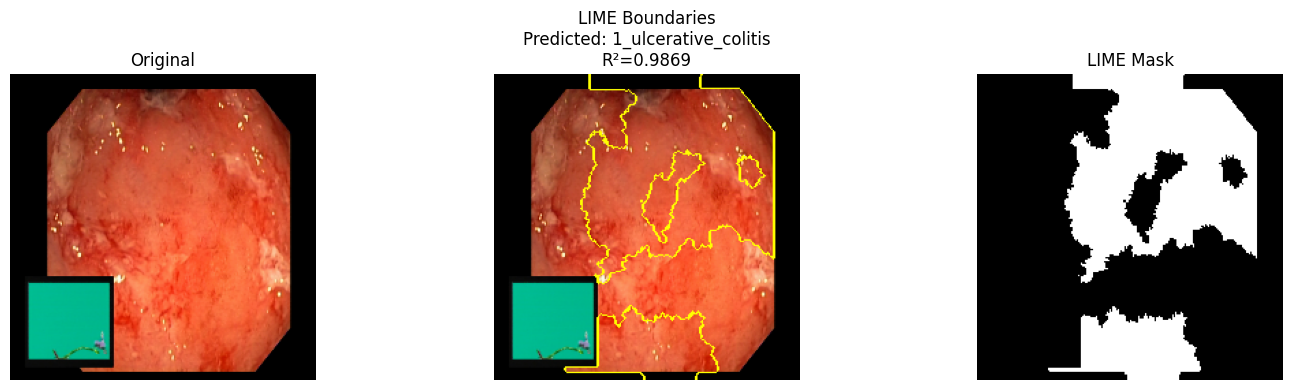

  0%|          | 0/1000 [00:00<?, ?it/s]

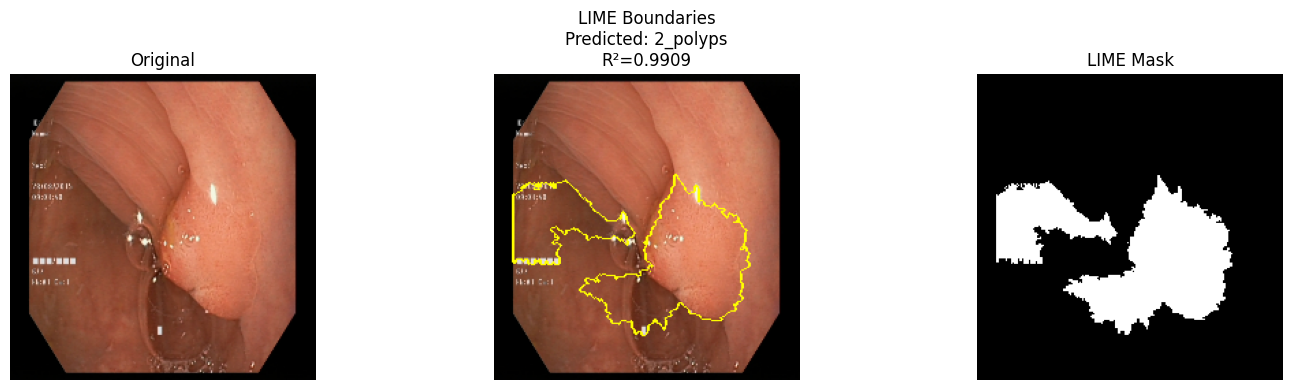

  0%|          | 0/1000 [00:00<?, ?it/s]

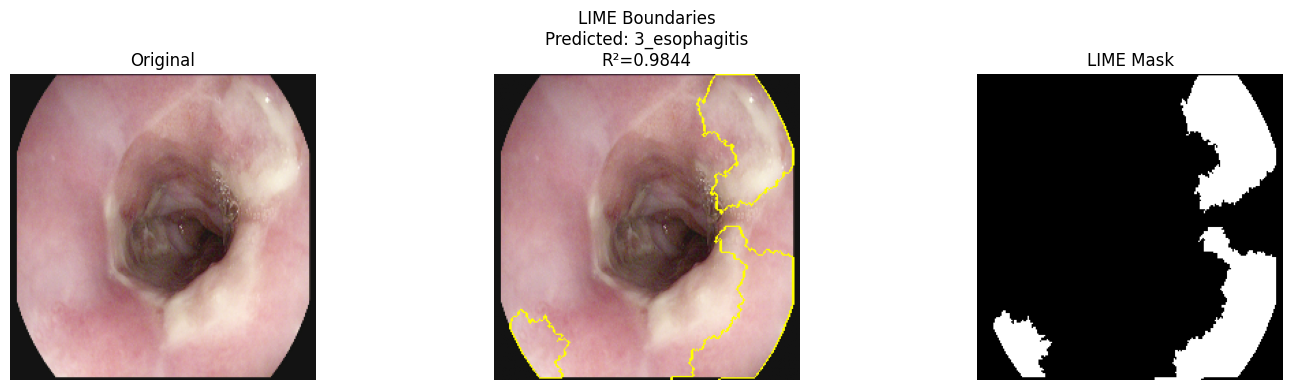


✅ Standard R² values per image:
test_ulcer_ (12)_aug.png: R² = 0.9869
test_polyps_ (10)_aug.png: R² = 0.9909
test_esophagitis_ (39)_aug.png: R² = 0.9844


In [26]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from skimage.segmentation import mark_boundaries
from lime import lime_image
import tensorflow as tf
from sklearn.metrics import r2_score

# =================== LOAD YOUR TRAINED MODEL ===================
class MeanChannel(tf.keras.layers.Layer):
    def call(self, inputs):
        return tf.reduce_mean(inputs, axis=-1, keepdims=True)

class MaxChannel(tf.keras.layers.Layer):
    def call(self, inputs):
        return tf.reduce_max(inputs, axis=-1, keepdims=True)

model = tf.keras.models.load_model('carenet.keras', custom_objects={
    'MeanChannel': MeanChannel,
    'MaxChannel': MaxChannel
})

# =================== CLASS NAMES ===================
class_names = [
    '0_normal',
    '1_ulcerative_colitis',
    '2_polyps',
    '3_esophagitis'
]

# =================== PREPROCESS FUNCTION ===================
def model_predict(images: np.ndarray) -> np.ndarray:
    processed = images.astype('float32') / 255.0
    processed = tf.keras.applications.efficientnet.preprocess_input(processed)
    return model.predict(processed, verbose=0)

# =================== LIME EXPLANATION + STANDARD R2 FUNCTION ===================
def explain_image_with_r2(image_path: str):
    # Load and resize
    img = Image.open(image_path).convert('RGB')
    img = img.resize((224, 224))
    img_array = np.array(img)

    # Model prediction
    prediction = model_predict(np.array([img_array]))[0]
    predicted_class = np.argmax(prediction)

    # Initialize LIME explainer
    explainer = lime_image.LimeImageExplainer()
    explanation = explainer.explain_instance(
        img_array,
        model_predict,
        top_labels=3,
        hide_color=0,
        num_samples=1000
    )

    # ======= Compute STANDARD R² =======
    true_class_name = os.path.basename(os.path.dirname(image_path))
    true_class_index = int(true_class_name.split('_')[0])
    y_true = np.zeros(len(class_names))
    y_true[true_class_index] = 1
    r2_standard = r2_score(y_true, prediction)

    # Get LIME mask
    temp, mask = explanation.get_image_and_mask(
        predicted_class,
        positive_only=True,
        num_features=5,
        hide_rest=False
    )

    # ===== Visualization =====
    plt.figure(figsize=(15, 4))

    # Original image
    plt.subplot(1, 3, 1)
    plt.imshow(img)
    plt.title("Original")
    plt.axis("off")

    # LIME boundaries overlay
    plt.subplot(1, 3, 2)
    plt.imshow(mark_boundaries(temp, mask))
    plt.title(f"LIME Boundaries\nPredicted: {class_names[predicted_class]}\nR²={r2_standard:.4f}")
    plt.axis("off")

    # Raw mask
    plt.subplot(1, 3, 3)
    plt.imshow(mask, cmap="gray")
    plt.title("LIME Mask")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    return r2_standard

# =================== RUN EXPLANATIONS ===================
image_paths = [
    '/kaggle/input/colon-augmented-custom/colon_augmented_png_v9/1_ulcerative_colitis/test_ulcer_ (12)_aug.png',
    '/kaggle/input/colon-augmented-custom/colon_augmented_png_v9/2_polyps/test_polyps_ (10)_aug.png',
    '/kaggle/input/colon-augmented-custom/colon_augmented_png_v9/3_esophagitis/test_esophagitis_ (39)_aug.png'
]

r2_results = {}
for path in image_paths:
    r2_standard = explain_image_with_r2(path)
    r2_results[os.path.basename(path)] = r2_standard

# Show summary of R² values
print("\n✅ Standard R² values per image:")
for img_name, r2_val in r2_results.items():
    print(f"{img_name}: R² = {r2_val:.4f}")


# Shap


🔍 Explaining: test_ulcer_ (12)_aug.png
   True class: 1_ulcerative_colitis


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:33, 33.27s/it]               
This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


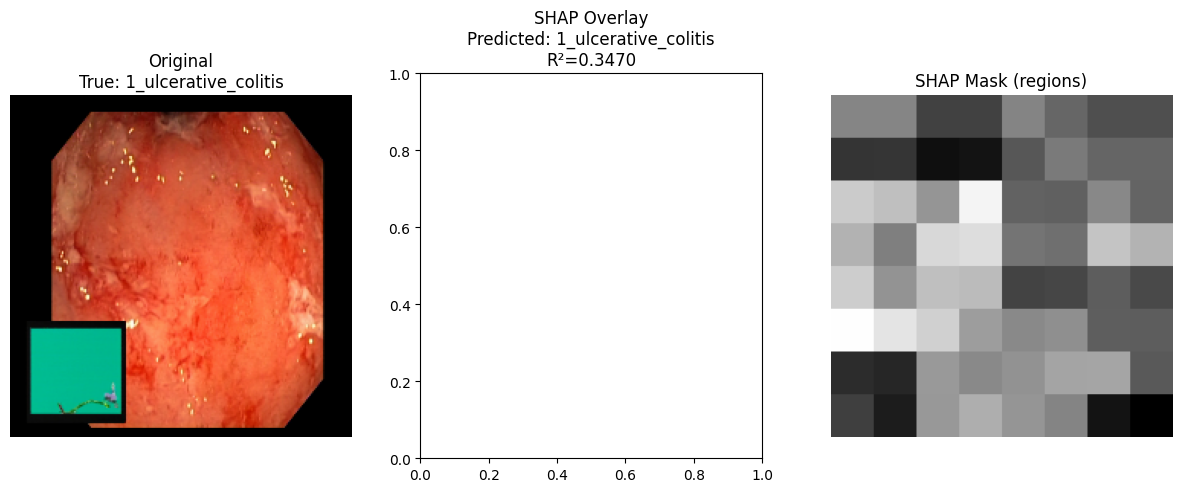

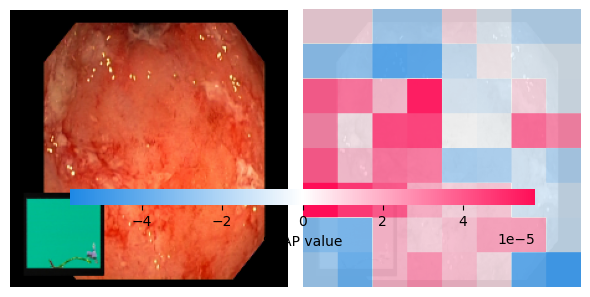

------------------------------------------------------------

🔍 Explaining: test_polyps_ (10)_aug.png
   True class: 2_polyps


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:34, 34.86s/it]               
This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


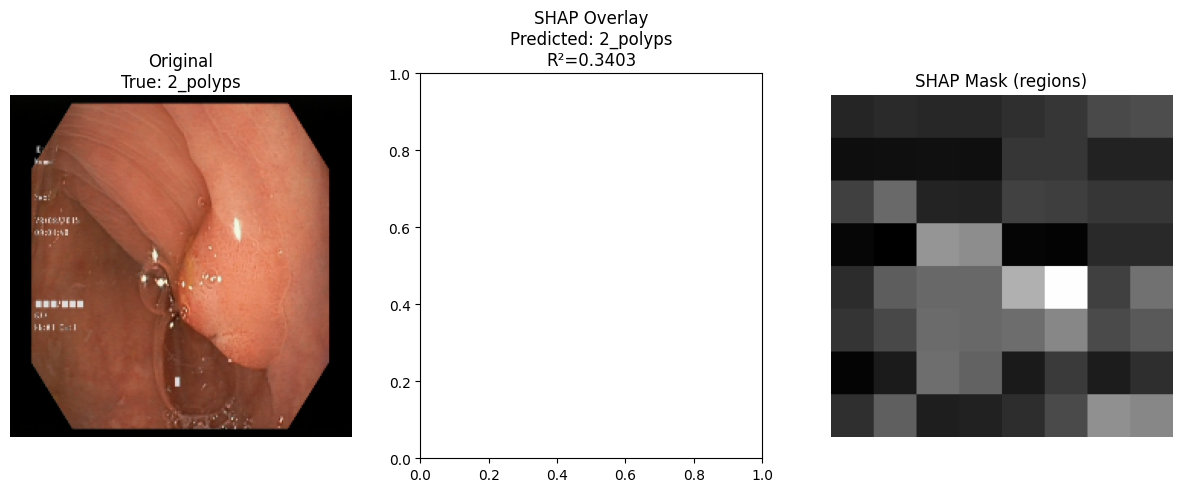

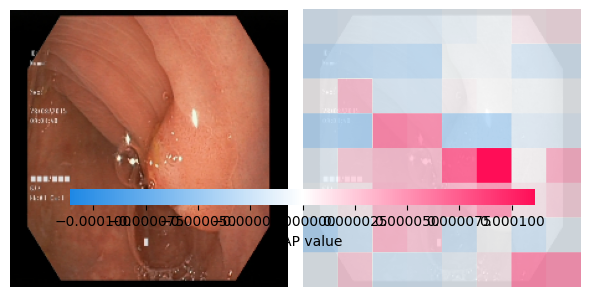

------------------------------------------------------------

🔍 Explaining: test_esophagitis_ (39)_aug.png
   True class: 3_esophagitis


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:35, 35.05s/it]               
This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


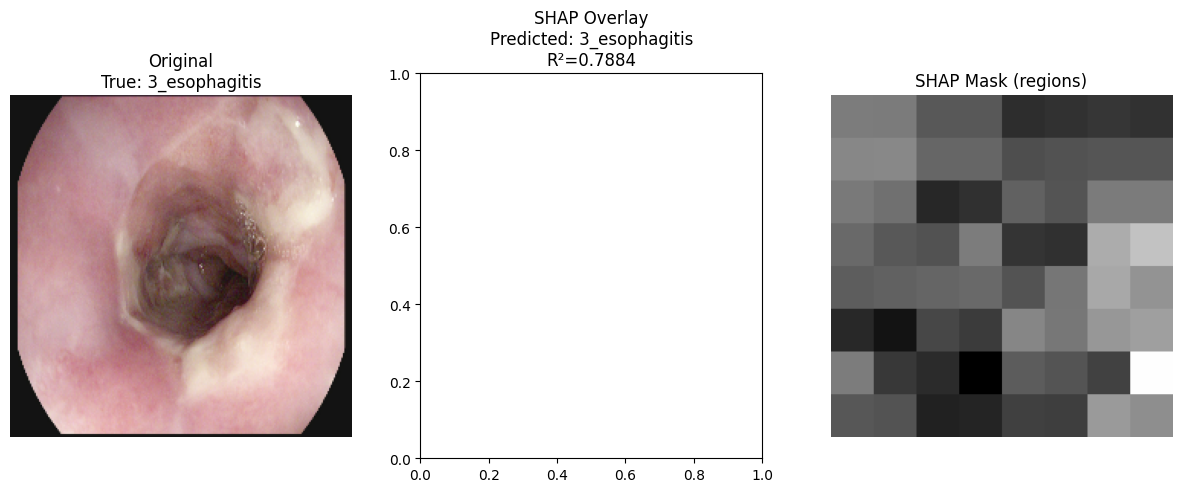

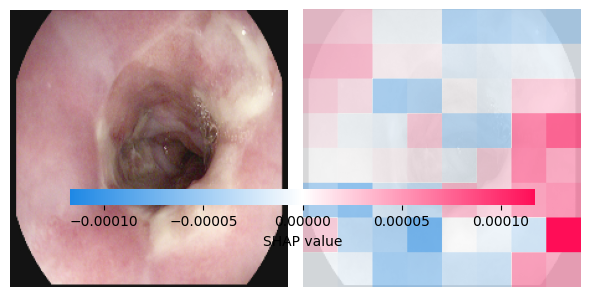

------------------------------------------------------------


In [24]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
import shap
import gc
from sklearn.metrics import r2_score

# ======= CUSTOM LAYERS =======
class MeanChannel(tf.keras.layers.Layer):
    def call(self, inputs):
        return tf.reduce_mean(inputs, axis=-1, keepdims=True)

class MaxChannel(tf.keras.layers.Layer):
    def call(self, inputs):
        return tf.reduce_max(inputs, axis=-1, keepdims=True)

# ======= LOAD MODEL =======
model = tf.keras.models.load_model('carenet.keras', custom_objects={
    'MeanChannel': MeanChannel,
    'MaxChannel': MaxChannel
})

# ======= CLASS NAMES =======
class_names = [
    '0_normal',
    '1_ulcerative_colitis',
    '2_polyps',
    '3_esophagitis'
]

# ======= PREPROCESSING =======
def preprocess_image(images: np.ndarray) -> np.ndarray:
    images = images.astype('float32') / 255.0
    return tf.keras.applications.efficientnet.preprocess_input(images)

# ======= MODEL PREDICTION WRAPPER =======
def predict_for_shap(images: np.ndarray) -> np.ndarray:
    processed = preprocess_image(images)
    return model(processed).numpy()

# ======= EXPLANATION FUNCTION =======
def explain_image_with_shap(image_path: str):
    # Load and prepare image
    img = Image.open(image_path).convert('RGB').resize((224, 224))
    img_array = np.array(img)
    img_batch = np.expand_dims(img_array, axis=0)  # Batch of 1

    # Get model prediction
    prediction = predict_for_shap(img_batch)[0]
    predicted_class = np.argmax(prediction)

    # Compute R² (standard)
    # Use one-hot vector for true class
    true_class_name = os.path.basename(os.path.dirname(image_path))
    true_class_index = int(true_class_name.split('_')[0])
    y_true = np.zeros(len(class_names))
    y_true[true_class_index] = 1
    r2 = r2_score(y_true, prediction)

    # Create SHAP explainer
    explainer = shap.Explainer(
        predict_for_shap,
        shap.maskers.Image("inpaint_telea", (224, 224, 3)),
        output_names=class_names
    )

    # Compute SHAP values
    shap_values = explainer(img_batch)

    # Extract mask for predicted class
    shap_mask = shap_values.values[0, :, :, :, predicted_class]
    shap_mask_norm = (shap_mask - shap_mask.min()) / (shap_mask.max() - shap_mask.min() + 1e-8)

    # ===== Visualization =====
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # 1. Original image
    axes[0].imshow(img_array)
    axes[0].set_title(f"Original\nTrue: {true_class_name}")
    axes[0].axis('off')

    # 2. SHAP overlay (standard)
    shap.image_plot(
        shap_values.values[:, :, :, :, predicted_class],
        img_batch.astype(np.float32) / 255,
        show=False
    )
    axes[1].set_title(f"SHAP Overlay\nPredicted: {class_names[predicted_class]}\nR²={r2:.4f}")

    # 3. SHAP mask (grayscale)
    axes[2].imshow(shap_mask_norm, cmap='bwr')
    axes[2].set_title("SHAP Mask (regions)")
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

    # Clean up memory
    del explainer, shap_values
    gc.collect()

# ======= MAIN =======
image_paths = [
    '/kaggle/input/colon-augmented-custom/colon_augmented_png_v9/1_ulcerative_colitis/test_ulcer_ (12)_aug.png',
    '/kaggle/input/colon-augmented-custom/colon_augmented_png_v9/2_polyps/test_polyps_ (10)_aug.png',
    '/kaggle/input/colon-augmented-custom/colon_augmented_png_v9/3_esophagitis/test_esophagitis_ (39)_aug.png'
]

for path in image_paths:
    print(f"\n🔍 Explaining: {os.path.basename(path)}")
    print(f"   True class: {os.path.basename(os.path.dirname(path))}")
    explain_image_with_shap(path)
    print("-" * 60)
